In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib as mpl

from pathlib import Path
from matplotlib.colors import Normalize
from matplotlib.colors import TwoSlopeNorm

plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"


In [2]:
def centres_to_edges(x, log=True):
    x = np.asarray(x, dtype=float).squeeze()

    if x.ndim != 1:
        raise ValueError(f"x must be 1D after squeeze; got shape {x.shape}")
    if x.size < 2:
        raise ValueError("Need at least two centres.")
    if not np.all(np.isfinite(x)):
        raise ValueError("Non-finite centres found.")

    if log:
        if np.any(x <= 0):
            raise ValueError("All centres must be positive for log-space edges.")

        lx = np.log(x)
        le = np.empty(x.size + 1, dtype=float)
        le[1:-1] = 0.5 * (lx[:-1] + lx[1:])
        le[0] = lx[0] - (le[1] - lx[0])
        le[-1] = lx[-1] + (lx[-1] - le[-2])
        return np.exp(le)

    e = np.empty(x.size + 1, dtype=float)
    e[1:-1] = 0.5 * (x[:-1] + x[1:])
    e[0] = x[0] - (e[1] - x[0])
    e[-1] = x[-1] + (x[-1] - e[-2])
    return e


def load_corrcoef_file_auto(fname):
    """
    Load either a multi-depth correlation file or a single-case correlation file.

    Returns a dictionary containing:
      M_grid, rp_bins, r, projection_depths if present.
    """
    fname = Path(fname)

    with h5py.File(fname, "r") as f:
        print("File:", fname)
        print("Datasets:", list(f.keys()))

        if "M_grid_Y" in f:
            M_grid = f["M_grid_Y"][:]
        elif "M_grid" in f:
            M_grid = f["M_grid"][:]
        else:
            raise KeyError("Could not find 'M_grid_Y' or 'M_grid'.")

        if "rp_bins" not in f:
            raise KeyError("Could not find 'rp_bins'.")

        if "r" not in f:
            raise KeyError("Could not find 'r'.")

        rp_bins = f["rp_bins"][:]
        r = f["r"][:]

        projection_depths = f["projection_depths"][:] if "projection_depths" in f else None

    M_grid = np.asarray(M_grid, dtype=float)
    rp_bins = np.asarray(rp_bins, dtype=float)
    r = np.asarray(r, dtype=float)

    print("projection_depths:", projection_depths)
    print("M_grid shape:", M_grid.shape)
    print("rp_bins shape:", rp_bins.shape)
    print("r shape:", r.shape)

    return dict(
        fname=fname,
        M_grid=M_grid,
        rp_bins=rp_bins,
        r=r,
        projection_depths=projection_depths,
    )


def _select_corr_arrays_for_plot(data, depth=None):
    """
    Return 1D M_grid, 1D rp_bins, and 2D r_M_rp with shape (n_mass, n_rp).

    Handles:
      single-case:
        M_grid : (n_mass,)
        rp     : (n_rp,)
        r      : (n_mass, n_rp)

      multi-depth:
        M_grid : (n_depth, n_mass)
        rp     : (n_depth, n_rp)
        r      : (n_depth, n_mass, n_rp)
    """
    M_grid = np.asarray(data["M_grid"], dtype=float)
    rp_bins = np.asarray(data["rp_bins"], dtype=float)
    r = np.asarray(data["r"], dtype=float)
    projection_depths = data.get("projection_depths", None)

    # Multi-depth file
    if r.ndim == 3:
        if projection_depths is None:
            if depth is None:
                idep = 0
                print("[info] r is 3D but projection_depths missing; using first depth index.")
            else:
                raise ValueError("r is 3D but projection_depths is missing; cannot choose depth.")
        else:
            projection_depths = np.asarray(projection_depths)
            if depth is None:
                idep = 0
                print(f"[info] depth not supplied; using first depth = {projection_depths[0]}")
            else:
                idx = np.where(projection_depths == depth)[0]
                if len(idx) == 0:
                    raise ValueError(
                        f"Depth {depth} not found. Available depths: {projection_depths}"
                    )
                idep = int(idx[0])

        M_use = np.asarray(M_grid[idep], dtype=float).squeeze()
        rp_use = np.asarray(rp_bins[idep], dtype=float).squeeze()
        r_use = np.asarray(r[idep], dtype=float)

    # Single-case file
    elif r.ndim == 2:
        M_use = np.asarray(M_grid, dtype=float).squeeze()
        rp_use = np.asarray(rp_bins, dtype=float).squeeze()
        r_use = r

        # If user accidentally loaded M_grid/rp_bins with a singleton leading dimension
        if M_use.ndim == 2 and M_use.shape[0] == 1:
            M_use = M_use[0]
        if rp_use.ndim == 2 and rp_use.shape[0] == 1:
            rp_use = rp_use[0]

    else:
        raise ValueError(f"Expected r to be 2D or 3D; got shape {r.shape}")

    M_use = np.asarray(M_use, dtype=float).squeeze()
    rp_use = np.asarray(rp_use, dtype=float).squeeze()
    r_use = np.asarray(r_use, dtype=float)

    if M_use.ndim != 1:
        raise ValueError(f"M_grid must be 1D after selection; got shape {M_use.shape}")
    if rp_use.ndim != 1:
        raise ValueError(f"rp_bins must be 1D after selection; got shape {rp_use.shape}")

    # r should be (n_mass, n_rp). If transposed, fix it.
    if r_use.shape == (M_use.size, rp_use.size):
        r_M_rp = r_use
    elif r_use.shape == (rp_use.size, M_use.size):
        print("[info] r array appears transposed; transposing to (n_mass, n_rp).")
        r_M_rp = r_use.T
    else:
        raise ValueError(
            "Cannot align r with M_grid and rp_bins. "
            f"M_grid size={M_use.size}, rp size={rp_use.size}, r shape={r_use.shape}"
        )

    return M_use, rp_use, r_M_rp


def plot_corr_heatmap_positive_only_auto(
    ax,
    data,
    *,
    depth=None,
    positive_threshold=0.0,
    cmap="viridis",
    masked_color="white",
    clim_mode="fixed",      # "fixed", "data", "percentile"
    vmin=0.0,
    vmax=1.0,
    percentile_range=(2, 98),
    title=None,
    add_colorbar=True,
    cbar_label=None,
    print_positive_fraction=True,
):
    """
    Positive-only correlation heatmap.

    Only r > positive_threshold is shown.
    r <= positive_threshold is masked and shown as white.
    """
    M_grid, rp_bins, r_M_rp = _select_corr_arrays_for_plot(data, depth=depth)

    # Convert r(mass, rp) -> matrix(rp, mass)
    matrix = r_M_rp.T

    good_M = np.isfinite(M_grid) & (M_grid > 0)
    good_rp = np.isfinite(rp_bins) & (rp_bins > 0)

    M_grid = M_grid[good_M]
    rp_bins = rp_bins[good_rp]
    matrix = matrix[np.ix_(good_rp, good_M)]

    # Mask non-positive values
    mask = (~np.isfinite(matrix)) | (matrix <= positive_threshold)
    matrix_pos = np.ma.masked_where(mask, matrix)

    positive_vals = matrix[(~mask) & np.isfinite(matrix)]

    if positive_vals.size == 0:
        raise RuntimeError(f"No correlation coefficients > {positive_threshold}.")

    if print_positive_fraction:
        frac_pos = positive_vals.size / matrix.size
        print(
            f"positive pixels = {positive_vals.size}/{matrix.size} "
            f"({100.0 * frac_pos:.1f}%), "
            f"positive r range = "
            f"[{np.nanmin(positive_vals):.3f}, {np.nanmax(positive_vals):.3f}]"
        )

    x_edges = centres_to_edges(M_grid, log=True)
    y_edges = centres_to_edges(rp_bins, log=True)

    if clim_mode == "fixed":
        vmin_use = 0.0 if vmin is None else float(vmin)
        vmax_use = 1.0 if vmax is None else float(vmax)

    elif clim_mode == "data":
        vmin_use = 0.0 if vmin is None else float(vmin)
        vmax_use = np.nanmax(positive_vals) if vmax is None else float(vmax)

    elif clim_mode == "percentile":
        p_lo, p_hi = percentile_range
        vmin_use = 0.0 if vmin is None else float(vmin)
        vmax_use = (
            np.nanpercentile(positive_vals, p_hi)
            if vmax is None else float(vmax)
        )

    else:
        raise ValueError("clim_mode must be 'fixed', 'data', or 'percentile'.")

    if vmax_use <= vmin_use:
        raise ValueError(f"Invalid color limits: vmin={vmin_use}, vmax={vmax_use}")

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color=masked_color, alpha=1.0)

    norm = Normalize(vmin=vmin_use, vmax=vmax_use)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        matrix_pos,
        shading="auto",
        cmap=cmap_obj,
        norm=norm,
    )

    ax.set_facecolor(masked_color)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$M_{500c}\,[h^{-1}{\rm M_\odot}]$", fontsize=23)
    ax.set_ylabel(r"$r_{\rm p}\,[h^{-1}{\rm cMpc}]$", fontsize=23)

    if title is not None:
        ax.set_title(title, fontsize=23)

    ax.tick_params(
        axis="both",
        which="both",
        labelsize=20,
        length=6,
        width=0.6,
        top=True,
        right=True,
        direction="in",
    )
    ax.tick_params(
        axis="both",
        which="major",
        length=10,
        width=1.2,
        top=True,
        right=True,
        direction="in",
    )
    ax.minorticks_on()

    if add_colorbar:
        cbar = plt.colorbar(mesh, ax=ax)

        if cbar_label is None:
            cbar_label = r"${\rm Corr}[\delta\ln s_2,\delta\ln s_1] > 0$"

        cbar.set_label(cbar_label, fontsize=23)
        cbar.ax.tick_params(labelsize=20, direction="in", length=8, width=1.0)

    return mesh

# corr[$\delta \ln Y_{\rm cyl}$, $\delta \ln \Sigma$]

In [3]:

CORR_BASE = Path("data")

fname_Ycyl_sig = CORR_BASE / "corrcoef_lnY500c_lnSigma_massdep_20rps_depths60-90-180-300_kw0.20_bins20.h5"

with h5py.File(fname_Ycyl_sig, "r") as f:
    depths = f["projection_depths"][:]
    print("depths =", depths)
    print("datasets =", list(f.keys()))

    # choose projection depth
    depth_pick = 300
    idep = np.where(depths == depth_pick)[0][0]

    M_grid = f["M_grid_Y"][idep]
    rp_bins = f["rp_bins"][idep]
    r_M_rp = f["r"][idep]   # shape = (n_mass_grid, 20)

print("M_grid shape:", M_grid.shape)
print("rp_bins shape:", rp_bins.shape)
print("r_M_rp shape:", r_M_rp.shape)

depths = [ 60  90 180 300]
datasets = ['M_grid_X', 'M_grid_Y', 'depth_180', 'depth_300', 'depth_60', 'depth_90', 'lnM_max', 'lnM_min', 'mu_lnSigma', 'mu_lnY500c', 'n_halo_total', 'n_halo_valid', 'pos_frac_Sigma', 'projection_depths', 'r', 'rp_bins', 'sig_lnSigma', 'sig_lnY500c', 'xg_X_lnM', 'xg_Y_lnM']
M_grid shape: (20,)
rp_bins shape: (20,)
r_M_rp shape: (20, 20)


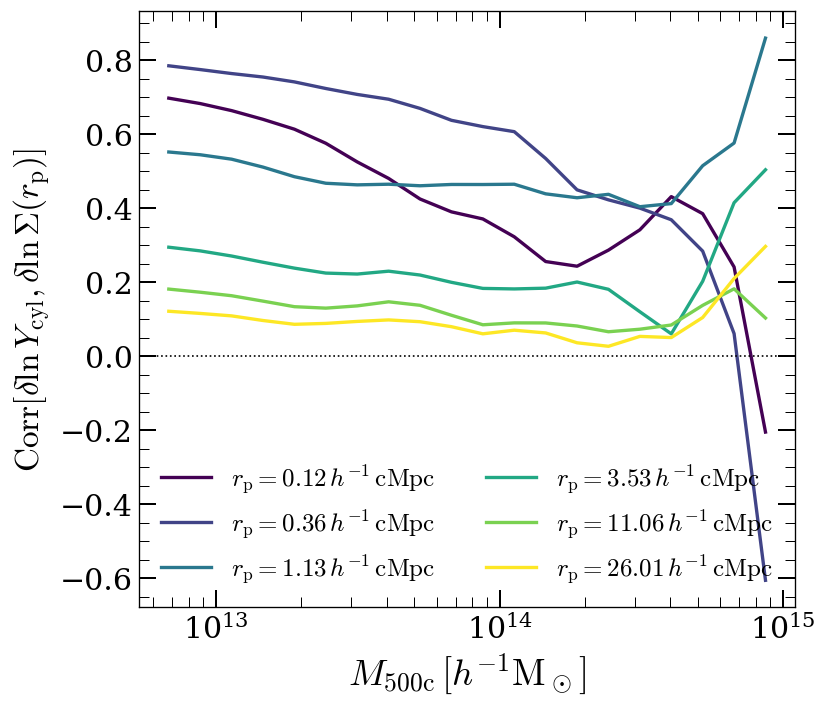

In [4]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))


fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

ic = 0
for ir in rp_indices:
    plt.plot(
        M_grid,
        r_M_rp[:, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln Y_{\rm cyl},\delta \ln\Sigma(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()

plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


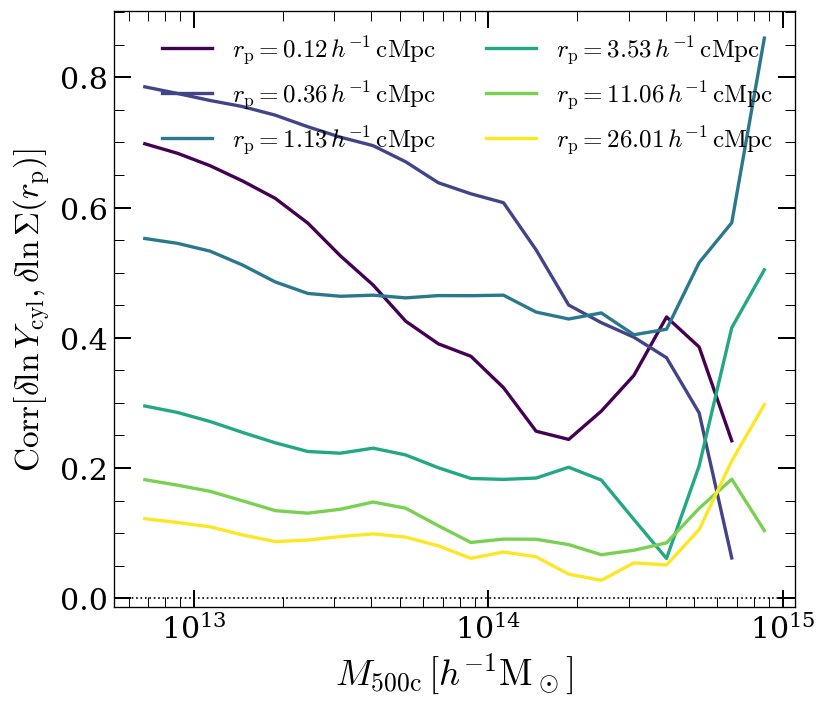

In [5]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))


fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)
ic = 0
for ir in rp_indices:

    sel_gt0 = (r_M_rp[:, ir]>0)

    plt.plot(
        M_grid[sel_gt0],
        r_M_rp[sel_gt0, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln Y_{\rm cyl},\delta \ln\Sigma(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()

plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


File: data/corrcoef_lnY500c_lnSigma_massdep_20rps_depths60-90-180-300_kw0.20_bins20.h5
Datasets: ['M_grid_X', 'M_grid_Y', 'depth_180', 'depth_300', 'depth_60', 'depth_90', 'lnM_max', 'lnM_min', 'mu_lnSigma', 'mu_lnY500c', 'n_halo_total', 'n_halo_valid', 'pos_frac_Sigma', 'projection_depths', 'r', 'rp_bins', 'sig_lnSigma', 'sig_lnY500c', 'xg_X_lnM', 'xg_Y_lnM']
projection_depths: [ 60  90 180 300]
M_grid shape: (4, 20)
rp_bins shape: (4, 20)
r shape: (4, 20, 20)
positive pixels = 394/400 (98.5%), positive r range = [0.027, 0.860]


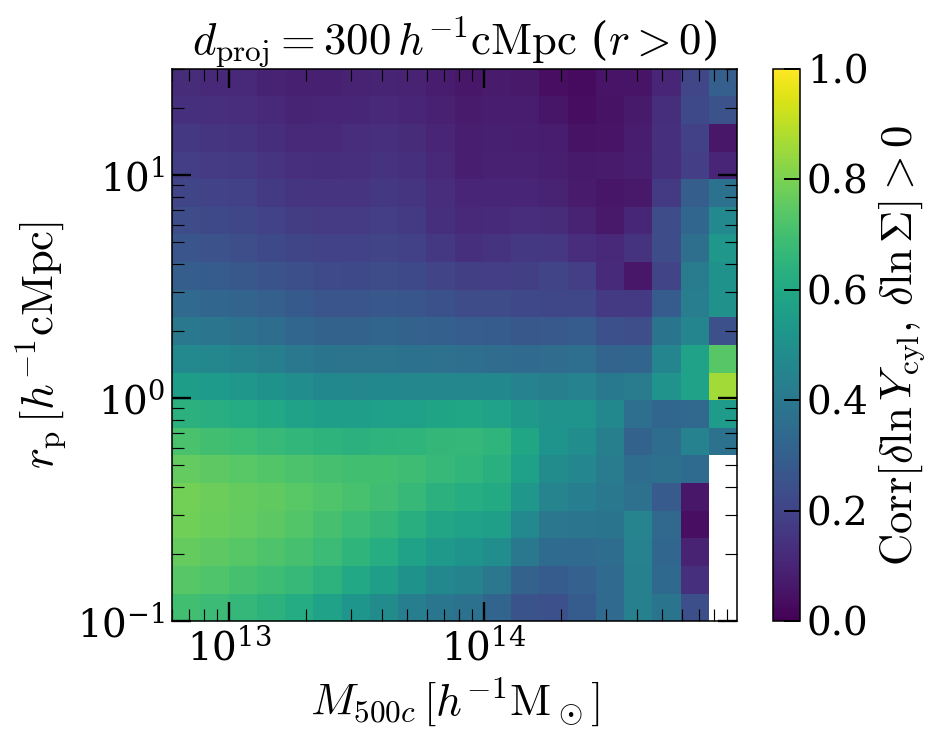

In [6]:
data_ycyl_sigma = load_corrcoef_file_auto(fname_Ycyl_sig)

fig, ax = plt.subplots(figsize=(6.8, 5.4), dpi=140)

mesh = plot_corr_heatmap_positive_only_auto(
    ax,
    data_ycyl_sigma,
    depth=300,
    positive_threshold=0.0,
    cmap="viridis",
    masked_color="white",
    clim_mode="fixed",
    vmin=0.0,
    vmax=1.0,
    add_colorbar=True,
    title=r"$d_{\rm proj}=300\,h^{-1}{\rm cMpc}$ ($r>0$)",
    cbar_label=r"${\rm Corr}[\delta\ln Y_{\rm cyl},\,\delta\ln\Sigma] > 0$",
)

fig.tight_layout()
plt.show()

# corr[$\delta \ln Y_{\rm cyl}$, $\delta \ln y$]

In [7]:
fname_Ycyl_y = CORR_BASE / "corrcoef_lnY500c_lncy_massdep_20rps_Yproj300_cyproj300_kw0.20_bins20.h5"

with h5py.File(fname_Ycyl_y, "r") as f:
    print("Datasets:", list(f.keys()))

    # projection_depths = f["projection_depths"][:]   # shape: (n_depth,)
    rp_bins_all       = f["rp_bins"][:]             # shape: (n_depth, n_rp)
    M_grid_all        = f["M_grid_Y"][:]            # shape: (n_depth, n_mass_grid)
    r_all             = f["r"][:]                   # shape: (n_depth, n_mass_grid, n_rp)

# print("projection_depths:", projection_depths)
print("rp_bins_all shape:", rp_bins_all.shape)
print("M_grid_all shape :", M_grid_all.shape)
print("r_all shape      :", r_all.shape)

Datasets: ['M_grid_X', 'M_grid_Y', 'lnM_max', 'lnM_min', 'mu_ln_proxy', 'mu_ln_target', 'n_halo_total', 'n_halo_valid', 'pos_frac_target', 'r', 'rp_bins', 'sig_ln_proxy', 'sig_ln_target', 'xg_X_lnM', 'xg_Y_lnM']
rp_bins_all shape: (20,)
M_grid_all shape : (20,)
r_all shape      : (20, 20)


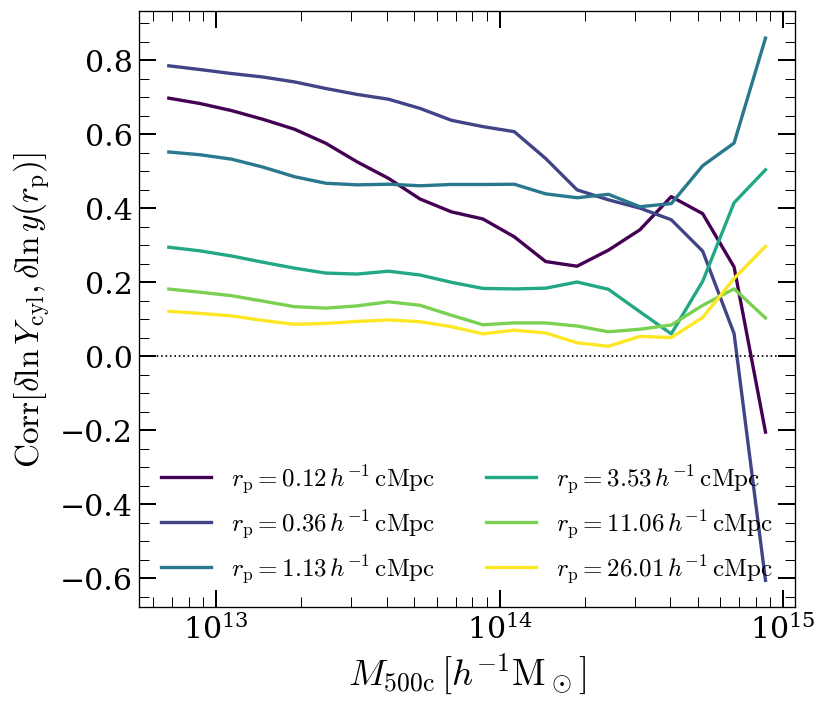

In [8]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

ic = 0
for ir in rp_indices:
    plt.plot(
        M_grid,
        r_M_rp[:, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln Y_{\rm cyl},\delta \ln y(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()

plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


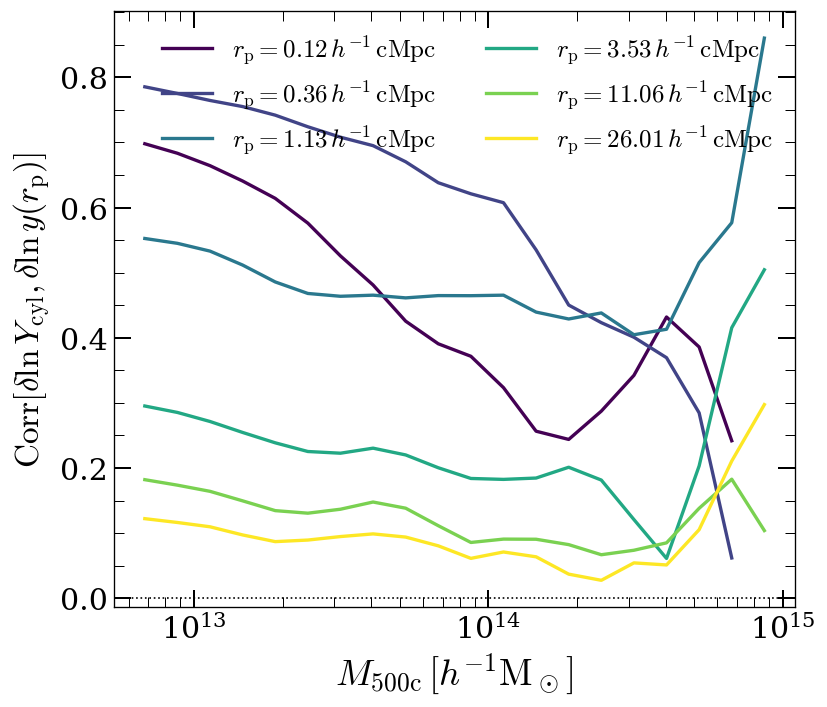

In [9]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)
ic = 0
for ir in rp_indices:

    sel_gt0 = (r_M_rp[:, ir]>0)

    plt.plot(
        M_grid[sel_gt0],
        r_M_rp[sel_gt0, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln Y_{\rm cyl},\delta \ln y(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()

plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


File: data/corrcoef_lnY500c_lncy_massdep_20rps_Yproj300_cyproj300_kw0.20_bins20.h5
Datasets: ['M_grid_X', 'M_grid_Y', 'lnM_max', 'lnM_min', 'mu_ln_proxy', 'mu_ln_target', 'n_halo_total', 'n_halo_valid', 'pos_frac_target', 'r', 'rp_bins', 'sig_ln_proxy', 'sig_ln_target', 'xg_X_lnM', 'xg_Y_lnM']
projection_depths: None
M_grid shape: (20,)
rp_bins shape: (20,)
r shape: (20, 20)
positive pixels = 400/400 (100.0%), positive r range = [0.010, 0.997]


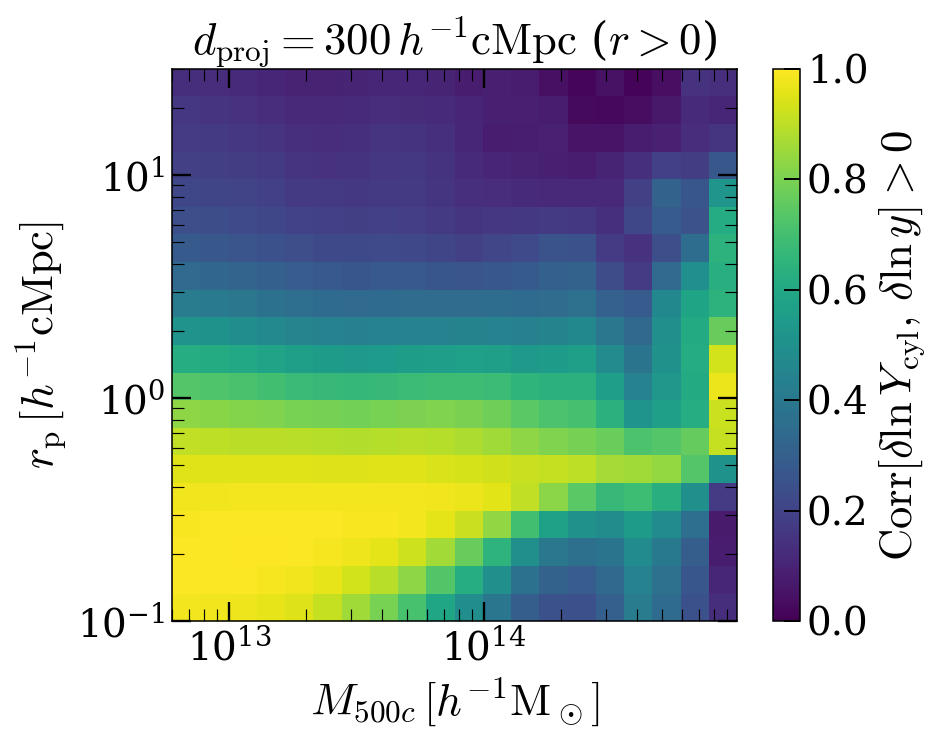

In [10]:
data_ycyl_cy = load_corrcoef_file_auto(fname_Ycyl_y)

fig, ax = plt.subplots(figsize=(6.8, 5.4), dpi=140)

mesh = plot_corr_heatmap_positive_only_auto(
    ax,
    data_ycyl_cy,
    depth=None,   # Note: fname_Ycyl_y is a single-case file, so no depth index is needed
    positive_threshold=0.0,
    cmap="viridis",
    masked_color="white",
    clim_mode="fixed",
    vmin=0.0,
    vmax=1.0,
    add_colorbar=True,
    title=r"$d_{\rm proj}=300\,h^{-1}{\rm cMpc}$ ($r>0$)",
    cbar_label=r"${\rm Corr}[\delta\ln Y_{\rm cyl},\,\delta\ln y] > 0$",
)

fig.tight_layout()
plt.show()

# corr[$\delta \ln N_{\rm cyl}$, $\delta \ln y$]

In [11]:

# ---------------------------------------------------------------------
# Load one single-case Ncyl correlation file
# ---------------------------------------------------------------------
def load_single_ncyl_corr_file(fname):
    """
    Load one single-case mass-dependent Ncyl residual-correlation file.

    Expected datasets:
        M_grid_Y or M_grid
        rp_bins
        r

    Expected shapes:
        M_grid : (n_mass_grid,)
        rp_bins: (n_rp,)
        r      : (n_mass_grid, n_rp)
    """
    fname = Path(fname)

    with h5py.File(fname, "r") as f:
        print("File:", fname)
        print("datasets =", list(f.keys()))

        if "M_grid_Y" in f:
            M_grid = f["M_grid_Y"][:]
        elif "M_grid" in f:
            M_grid = f["M_grid"][:]
        else:
            raise KeyError("Could not find 'M_grid_Y' or 'M_grid' in file.")

        if "rp_bins" not in f:
            raise KeyError("Could not find 'rp_bins' in file.")
        if "r" not in f:
            raise KeyError("Could not find 'r' in file.")

        rp_bins = f["rp_bins"][:]
        r_M_rp = f["r"][:]

    M_grid = np.asarray(M_grid, dtype=float)
    rp_bins = np.asarray(rp_bins, dtype=float)
    r_M_rp = np.asarray(r_M_rp, dtype=float)

    print("M_grid shape:", M_grid.shape)
    print("rp_bins shape:", rp_bins.shape)
    print("r_M_rp shape:", r_M_rp.shape)

    if r_M_rp.shape != (M_grid.size, rp_bins.size):
        raise ValueError(
            "Unexpected shape for r. Expected "
            f"({M_grid.size}, {rp_bins.size}), got {r_M_rp.shape}."
        )

    return M_grid, rp_bins, r_M_rp


# ---------------------------------------------------------------------
# Positive-only Ncyl correlation heatmap
# ---------------------------------------------------------------------
def plot_single_ncyl_corr_heatmap_positive_only(
    ax,
    M_grid,
    rp_bins,
    r_M_rp,
    *,
    title=None,
    positive_threshold=0.0,
    cmap="viridis",
    masked_color="white",
    clim_mode="fixed",       # "fixed", "data", or "percentile"
    vmin=0.0,
    vmax=1.0,
    percentile_range=(2, 98),
    add_colorbar=True,
    cbar_label=None,
    draw_cbar_tick_lines=True,
    print_positive_fraction=True,
):
    """
    Plot positive-only heatmap of mass-dependent residual correlation.

    Only pixels with r > positive_threshold are plotted.
    Pixels with r <= positive_threshold are masked and shown as masked_color.

    Parameters
    ----------
    M_grid : array, shape (n_mass_grid,)
        Mass grid in Msun/h.
    rp_bins : array, shape (n_rp,)
        Projected radius grid in cMpc/h.
    r_M_rp : array, shape (n_mass_grid, n_rp)
        Residual correlation coefficient.
    positive_threshold : float
        Usually 0.0. Only r > positive_threshold is shown.
    clim_mode : {"fixed", "data", "percentile"}
        "fixed"      : use vmin/vmax, default [0, 1].
        "data"       : use [0, max positive r].
        "percentile" : use percentiles of positive r.
    """
    M_grid = np.asarray(M_grid, dtype=float)
    rp_bins = np.asarray(rp_bins, dtype=float)
    r_M_rp = np.asarray(r_M_rp, dtype=float)

    # Convert r(mass, rp) -> matrix(rp, mass) for pcolormesh.
    matrix = r_M_rp.T

    good_M = np.isfinite(M_grid) & (M_grid > 0)
    good_rp = np.isfinite(rp_bins) & (rp_bins > 0)

    M_grid = M_grid[good_M]
    rp_bins = rp_bins[good_rp]
    matrix = matrix[np.ix_(good_rp, good_M)]

    # Mask non-positive and non-finite values.
    mask = (~np.isfinite(matrix)) | (matrix <= positive_threshold)
    matrix_pos = np.ma.masked_where(mask, matrix)

    positive_vals = matrix[(~mask) & np.isfinite(matrix)]

    if positive_vals.size == 0:
        raise RuntimeError(
            f"No correlation coefficients > {positive_threshold}."
        )

    if print_positive_fraction:
        frac_pos = positive_vals.size / matrix.size
        print(
            f"positive pixels = {positive_vals.size}/{matrix.size} "
            f"({100.0 * frac_pos:.1f}%), "
            f"positive r range = "
            f"[{np.nanmin(positive_vals):.3f}, {np.nanmax(positive_vals):.3f}]"
        )

    x_edges = centres_to_edges(M_grid, log=True)
    y_edges = centres_to_edges(rp_bins, log=True)

    # Colorbar limits
    if clim_mode == "fixed":
        vmin_use = 0.0 if vmin is None else float(vmin)
        vmax_use = 1.0 if vmax is None else float(vmax)

    elif clim_mode == "data":
        vmin_use = 0.0 if vmin is None else float(vmin)
        vmax_use = np.nanmax(positive_vals) if vmax is None else float(vmax)

    elif clim_mode == "percentile":
        p_lo, p_hi = percentile_range
        vmin_use = 0.0 if vmin is None else float(vmin)
        vmax_use = (
            np.nanpercentile(positive_vals, p_hi)
            if vmax is None else float(vmax)
        )

    else:
        raise ValueError("clim_mode must be 'fixed', 'data', or 'percentile'.")

    if vmax_use <= vmin_use:
        raise ValueError(f"Invalid color limits: vmin={vmin_use}, vmax={vmax_use}")

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_bad(color=masked_color, alpha=1.0)

    norm = Normalize(vmin=vmin_use, vmax=vmax_use)

    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        matrix_pos,
        shading="auto",
        cmap=cmap_obj,
        norm=norm,
    )

    ax.set_facecolor(masked_color)
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"$M_{500c}\,[h^{-1}{\rm M_\odot}]$", fontsize=23)
    ax.set_ylabel(r"$r_{\rm p}\,[h^{-1}{\rm cMpc}]$", fontsize=23)

    if title is not None:
        ax.set_title(title, fontsize=23)

    ax.tick_params(
        axis="both",
        which="both",
        labelsize=20,
        length=6,
        width=0.6,
        top=True,
        right=True,
        direction="in",
    )
    ax.tick_params(
        axis="both",
        which="major",
        length=10,
        width=1.2,
        top=True,
        right=True,
        direction="in",
    )
    ax.minorticks_on()

    if add_colorbar:
        cbar = plt.colorbar(mesh, ax=ax)

        if cbar_label is None:
            cbar_label = (
                r"${\rm Corr}[\delta\ln N_{\rm cyl},"
                r"\delta\ln s_1] > 0$"
            )

        cbar.set_label(cbar_label, fontsize=23)
        cbar.ax.tick_params(labelsize=20, direction="in", length=8, width=1.0)

        if draw_cbar_tick_lines:
            for tick in cbar.get_ticks():
                cbar.ax.axhline(tick, color="k", lw=0.8, alpha=0.9)

    return mesh

In [12]:
fname_ncyl_cy = CORR_BASE / "corrcoef_lnNcyl_lncy_massdep_20rps_q180_galdens1.0e-02_Mz21_chi6_cyproj300_kw0.20_bins20.h5"

with h5py.File(fname_ncyl_cy, "r") as f:
    print("datasets =", list(f.keys()))
    M_grid = f["M_grid_Y"][:]   # shape: (n_mass_grid,)
    rp_bins = f["rp_bins"][:]   # shape: (20,)
    r_M_rp = f["r"][:]          # shape: (n_mass_grid, 20)

print("M_grid shape:", M_grid.shape)
print("rp_bins shape:", rp_bins.shape)
print("r_M_rp shape:", r_M_rp.shape)

datasets = ['M_grid_X', 'M_grid_Y', 'lnM_max', 'lnM_min', 'matched_halo_id', 'mu_ln_proxy', 'mu_ln_target', 'n_halo_total', 'n_halo_valid', 'pos_frac_target', 'r', 'rp_bins', 'sig_ln_proxy', 'sig_ln_target', 'xg_X_lnM', 'xg_Y_lnM']
M_grid shape: (20,)
rp_bins shape: (20,)
r_M_rp shape: (20, 20)


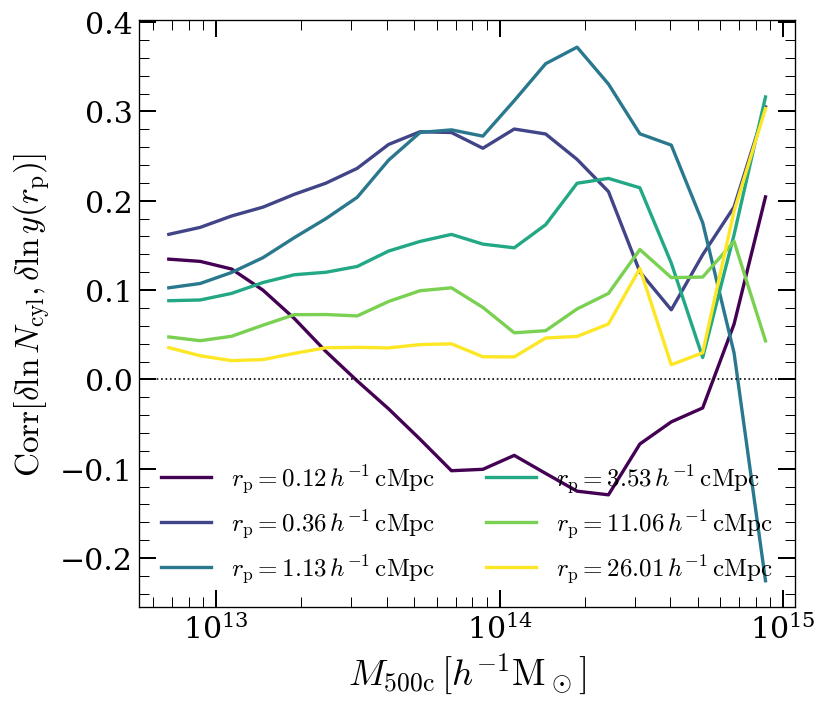

In [13]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

ic = 0
for ir in rp_indices:
    plt.plot(
        M_grid,
        r_M_rp[:, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln N_{\rm cyl},\delta \ln y(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()

plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


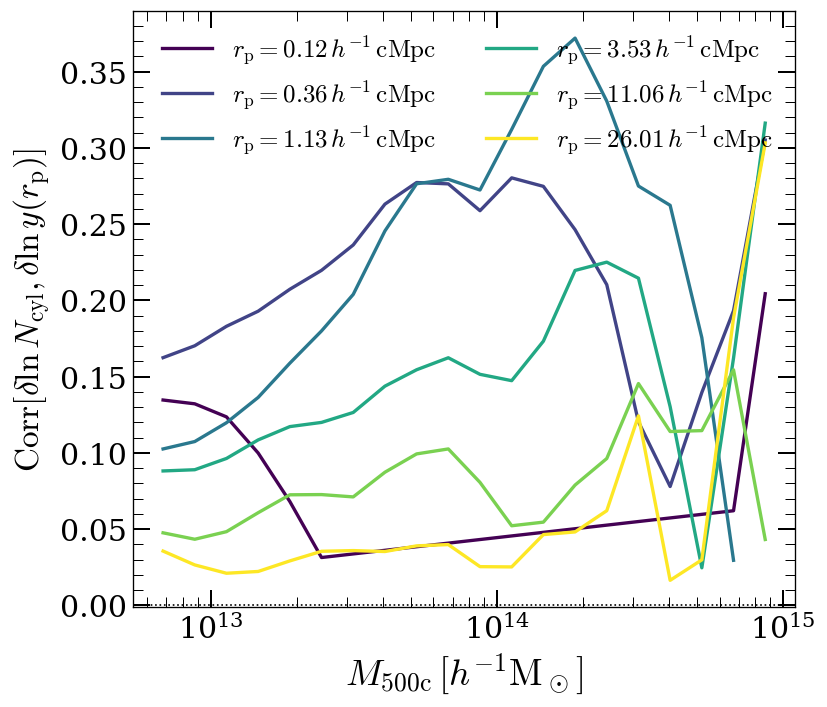

In [14]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

ic = 0
for ir in rp_indices:
    sel_gt0 = (r_M_rp[:, ir]>0)
    plt.plot(
        M_grid[sel_gt0],
        r_M_rp[sel_gt0, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln N_{\rm cyl},\delta \ln y(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()

plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


File: data/corrcoef_lnNcyl_lncy_massdep_20rps_q180_galdens1.0e-02_Mz21_chi6_cyproj300_kw0.20_bins20.h5
datasets = ['M_grid_X', 'M_grid_Y', 'lnM_max', 'lnM_min', 'matched_halo_id', 'mu_ln_proxy', 'mu_ln_target', 'n_halo_total', 'n_halo_valid', 'pos_frac_target', 'r', 'rp_bins', 'sig_ln_proxy', 'sig_ln_target', 'xg_X_lnM', 'xg_Y_lnM']
M_grid shape: (20,)
rp_bins shape: (20,)
r_M_rp shape: (20, 20)
positive pixels = 367/400 (91.8%), positive r range = [0.002, 0.413]


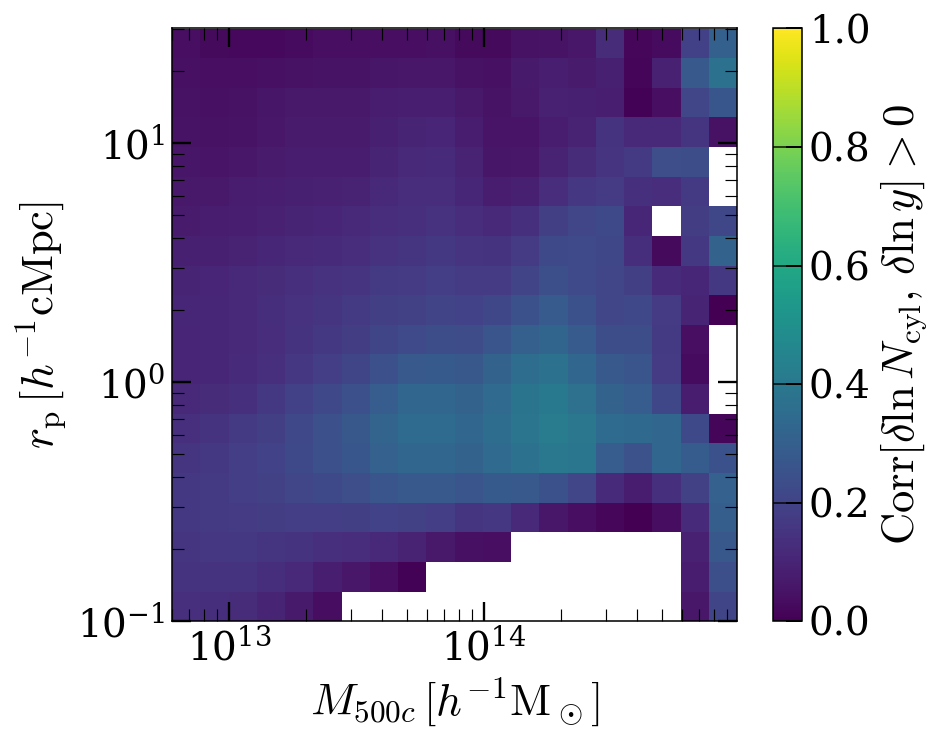

In [15]:
M_grid, rp_bins, r_M_rp = load_single_ncyl_corr_file(fname_ncyl_cy)

fig, ax = plt.subplots(figsize=(6.8, 5.4), dpi=140)

mesh = plot_single_ncyl_corr_heatmap_positive_only(
    ax,
    M_grid,
    rp_bins,
    r_M_rp,
    # title=rf"$N_{{\rm cyl}}$--$y$, $d_{{\rm proj}}=300\,h^{{-1}}\mathrm{{cMpc}}$, $r>0$",
    positive_threshold=0.0,
    cmap="viridis",
    masked_color="white",
    clim_mode="fixed",
    vmin=0.0,
    vmax=1.0,
    add_colorbar=True,
    cbar_label=r"${\rm Corr}[\delta\ln N_{\rm cyl},\,\delta\ln y]>0$",
)

fig.tight_layout()
plt.show()

# corr[$\delta \ln N_{\rm cyl}$, $\delta \ln \Sigma$]

File: data/corrcoef_lnNcyl_lnSigma_massdep_20rps_q180_galdens1.0e-02_Mz21_chi6_Sigproj300_kw0.20_bins20.h5
datasets = ['M_grid_X', 'M_grid_Y', 'lnM_max', 'lnM_min', 'matched_halo_id', 'mu_ln_proxy', 'mu_ln_target', 'n_halo_total', 'n_halo_valid', 'pos_frac_target', 'r', 'rp_bins', 'sig_ln_proxy', 'sig_ln_target', 'xg_X_lnM', 'xg_Y_lnM']
M_grid shape: (20,)
rp_bins shape: (20,)
r_M_rp shape: (20, 20)
positive pixels = 395/400 (98.8%), positive r range = [0.002, 0.850]


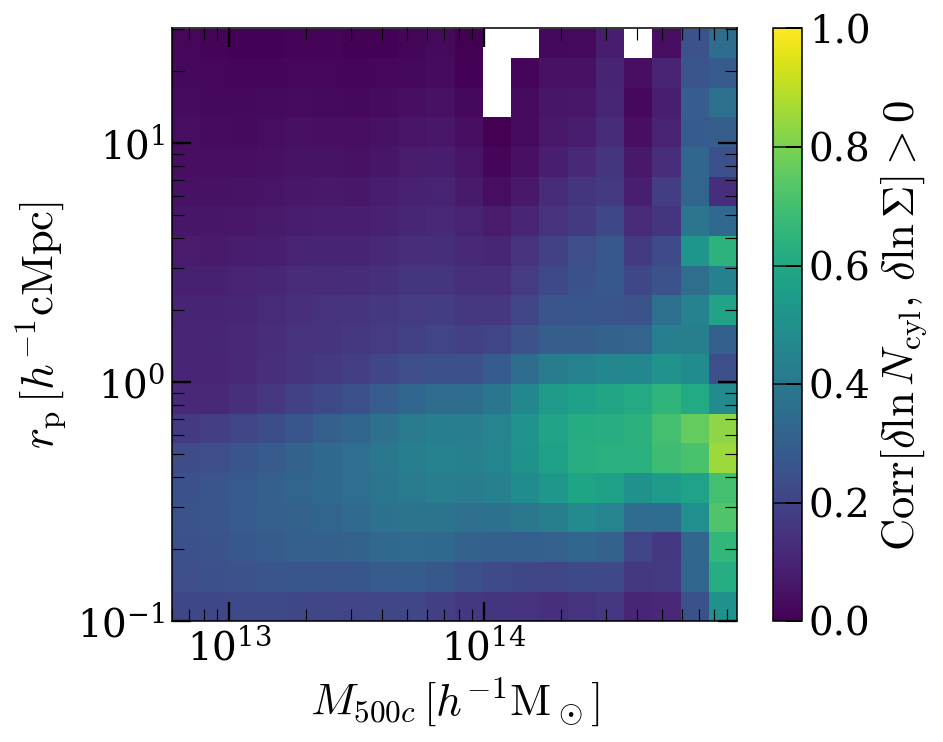

In [16]:

fname_ncyl_sig = CORR_BASE / "corrcoef_lnNcyl_lnSigma_massdep_20rps_q180_galdens1.0e-02_Mz21_chi6_Sigproj300_kw0.20_bins20.h5"

M_grid, rp_bins, r_M_rp = load_single_ncyl_corr_file(fname_ncyl_sig)

fig, ax = plt.subplots(figsize=(6.8, 5.4), dpi=140)

mesh = plot_single_ncyl_corr_heatmap_positive_only(
    ax,
    M_grid,
    rp_bins,
    r_M_rp,
    # title=rf"$N_{{\rm cyl}}$--$y$, $d_{{\rm proj}}=300\,h^{{-1}}\mathrm{{cMpc}}$, $r>0$",
    positive_threshold=0.0,
    cmap="viridis",
    masked_color="white",
    clim_mode="fixed",
    vmin=0.0,
    vmax=1.0,
    add_colorbar=True,
    cbar_label=r"${\rm Corr}[\delta\ln N_{\rm cyl},\,\delta\ln \Sigma]>0$",
)

fig.tight_layout()
plt.show()


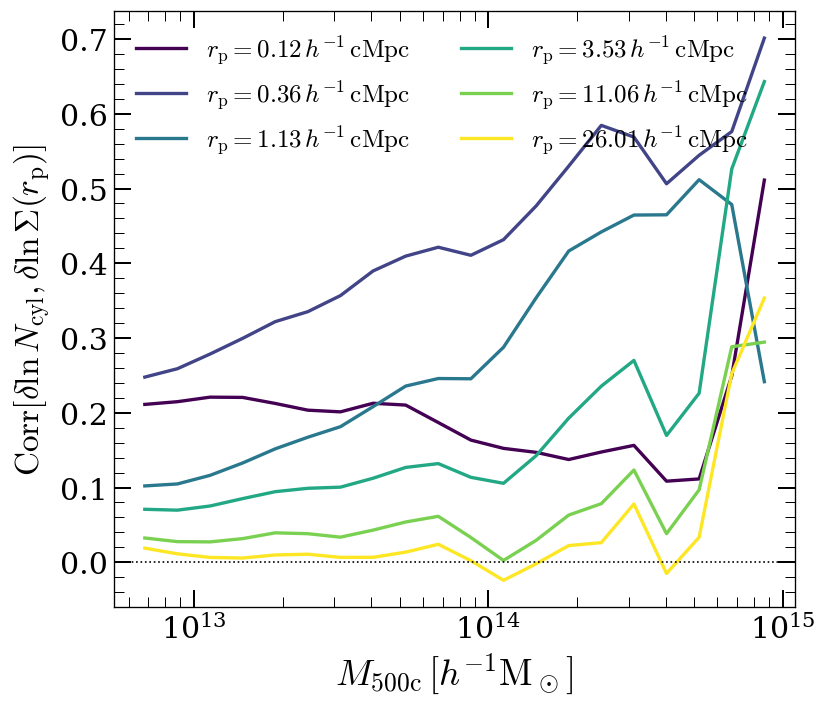

In [17]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

ic = 0
for ir in rp_indices:
    plt.plot(
        M_grid,
        r_M_rp[:, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln N_{\rm cyl},\delta \ln \Sigma(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()
plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")


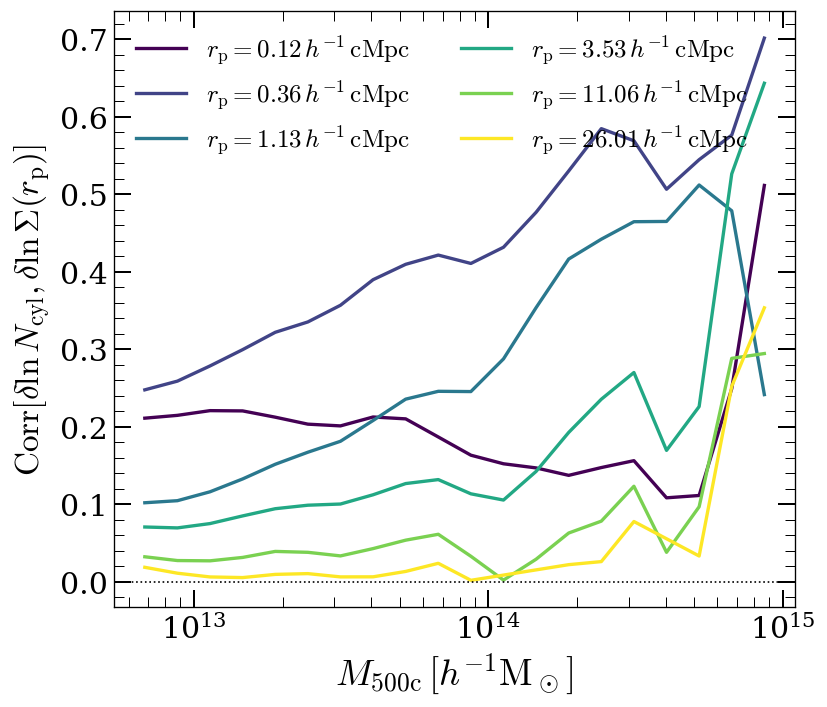

In [18]:
rp_indices = [0, 4, 8, 12, 16,19] #np.arange(1,20,2)#

cmap = mpl.colormaps["viridis"]
colors_rps = cmap(np.linspace(0.0, 1, len(rp_indices)))

fig, ax = plt.subplots(1, 1, figsize=(7, 6), dpi=120)#, sharey=True)

ic = 0
for ir in rp_indices:
    sel_gt0 = (r_M_rp[:, ir]>0)
    plt.plot(
        M_grid[sel_gt0],
        r_M_rp[sel_gt0, ir],
        lw=2,
        # marker="o",
        color=colors_rps[ic],
        label=rf"$r_{{\rm p}}={rp_bins[ir]:.2f}\,h^{{-1}}\,\mathrm{{cMpc}}$",
    )
    ic+=1

plt.xscale("log")
plt.axhline(0.0, color="k", lw=1, ls=":")
plt.xlabel(r"$M_{\rm 500c}\,[h^{-1}\rm M_\odot]$",
           fontsize=22
          )
plt.ylabel(
    r"$\mathrm{Corr}[\delta \ln N_{\rm cyl},\delta \ln\Sigma(r_{\rm p})]$",
    fontsize=20
)

ax.tick_params(axis='both', which='both', labelsize=18, length=6, width=.6, 
               top=True, right=True, direction='in')
ax.tick_params(axis='both', which='major', length=10, width=1.2, 
               top=True, right=True, direction='in')
ax.minorticks_on()
plt.legend(fontsize=15, ncols=2, frameon=False)
plt.tight_layout()
plt.show()
# fig.savefig(save_path+"corrcoef_Ycyl_Sigma_6rps_halomass.pdf", bbox_inches="tight")
